In [2]:
%load_ext autoreload
%autoreload 2

import os, sys
import glob
import json
import re

import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.colors as clr

from scipy import stats
from scipy.stats import ttest_ind, f_oneway
from scipy.stats import chi2_contingency, fisher_exact, barnard_exact


sys.path.append('/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/')

from config import *
# import analysis_utils as utils
import plotting_utils as utils
from tommy_utils import nlp


/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  torch.has_cudnn,
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/torch/overrides.py:117: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  torch.has_mps,
/dartfs/rc/lab/F/FinnLab/tommy/conda/envs/asynchrony/lib/python3.9/site-packages/torch/overrides.py:118: UserWarning: 'has_mkld

In [63]:
window_size = 25
task_list = ["black", "wheretheressmoke", "howtodraw"]
modality_list = ['video', 'audio', 'text']

preproc_dir = os.path.join(BASE_DIR, 'stimuli/preprocessed')
results_dir = os.path.join(BASE_DIR, 'derivatives/results/behavioral/')
models_dir = os.path.join(BASE_DIR, 'derivatives/model-predictions/')

MLM_MODELS = list(nlp.MLM_MODELS_DICT.keys())[1:]
CLM_MODELS = list(nlp.CLM_MODELS_DICT.keys()) 
model_names = CLM_MODELS + MLM_MODELS

remove_models = ['qwen3-8B', 'llama3.1-8B']
model_names = [model for model in model_names if model not in remove_models]

# model_names = ['gemma3-1b-pt']
# model_names = ' '.join(model_names)

N_MODELS = len(model_names)

word_model = 'fasttext'

results_fn = os.path.join(results_dir, f'all-task_group-analyzed-behavior_window-size-{str(window_size).zfill(5)}_human-model-lemmatized.csv')

df_results = pd.read_csv(results_fn)

# use the accuracy within these results to get the order to plot the models
ordered_accuracy = utils.get_ordered_accuracy(df_results)

# always put humans first (audio, text) then CLM models, then MLM models
order = modality_list + MLM_MODELS
models_order = [item for item in ordered_accuracy if item not in order]
models_order = models_order + MLM_MODELS

human_models_order = modality_list + models_order

/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x=x, y=y, hue=hue, palette=cmap, alpha=alpha, order=order, hue_order=hue_order, ax=ax)
/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x=x, y=y, hue=hue, palette=cmap, alpha=alpha, order=order, hue_order=hue_order, ax=ax)
/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

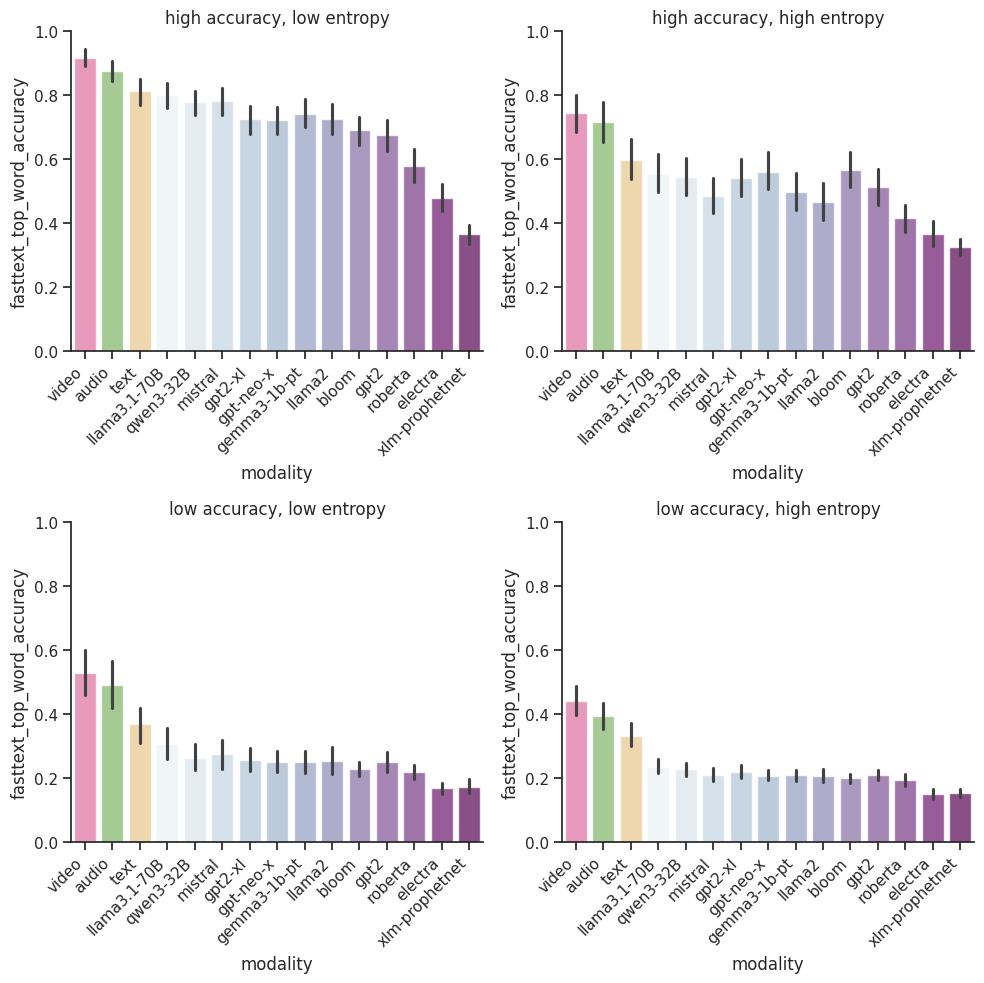

In [65]:
accuracy_entropy_groups = [
    'high-low',
    'high-high',
    'low-low',
    'low-high'
]

variable = 'fasttext_top_word_accuracy'
N_MODELS = len(model_names)

cmap = utils.create_colormap(dtype='multimodal', continuous=False, N_MODELS=N_MODELS)

fig, axes = plt.subplots(2,2, figsize=(10,10))
axes = axes.flatten()

for ax, group in zip(axes, accuracy_entropy_groups):

    accuracy_group, entropy_group = group.split('-')

    accuracy_mask = df_results['accuracy_group'] == accuracy_group
    entropy_mask = df_results['entropy_group'] == entropy_group
    df_group = df_results[accuracy_mask & entropy_mask]

    utils.plot_bar_results(df_group, x='modality', y=variable, hue=None, order=human_models_order, cmap=cmap, figsize=None, add_points=False, ax=ax)
    ax.set_ylim([0, 1])
    # ax.set_title(f'Task - {task}')
    # plt.xticks(rotation=45, ha='right')
    # Rotate x-axis labels for this axis
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
    # sns.barplot(df_group, x='modality', y='fasttext_top_word_accuracy',  ax=ax, order=human_models_order)
    ax.set_title(f'{accuracy_group} accuracy, {entropy_group} entropy')
    # ax.set_xlabel('Average Accuracy')
    ax.set_ylabel(variable)
    sns.despine()

plt.tight_layout()

In [61]:
# Set window sizes
WINDOW_SIZES = [
    2, 3, 4, 5, 10, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300
]

if len(modality_list) == 3:
    CMAP_DTYPE = 'multimodal'
else:
    CMAP_DTYPE = 'spoken-written'

FIG_SIZE = (5, 4)

preproc_dir = os.path.join(BASE_DIR, 'stimuli/preprocessed')
results_dir = os.path.join(BASE_DIR, 'derivatives/results/behavioral/')

###################################
### Load results from task list ###
###################################

models_dir = os.path.join(BASE_DIR, 'derivatives/model-predictions/')
plots_dir = os.path.join(BASE_DIR, 'derivatives/plots/final/human-llm-comparison/')

MLM_MODELS = list(nlp.MLM_MODELS_DICT.keys())[1:]
CLM_MODELS = list(nlp.CLM_MODELS_DICT.keys()) 
model_names = CLM_MODELS + MLM_MODELS

remove_models = ['qwen3-8B', 'llama3.1-8B']
model_names = [model for model in model_names if model not in remove_models]

# model_names = ['gemma3-1b-pt', 'qwen3-32B', 'llama3.1-70B']


print (f'Loading the following models')
print (f'MLM models: {MLM_MODELS}')
print (f'CLM models: {CLM_MODELS}')

# ###################################
# ### Load results from task list ###
# ###################################

df_results = []

for task in task_list:
    for i, window_size in enumerate(WINDOW_SIZES):
        results_fn = os.path.join(results_dir, f'task-{task}_group-analyzed-behavior_window-size-{str(window_size).zfill(5)}_human-model-lemmatized.csv')

        if os.path.exists(results_fn):
            df_task = pd.read_csv(results_fn)
            df_task['task'] = task
            df_task['window_size'] = window_size
            df_task['window_number'] = i
            df_results.append(df_task)

df_results = pd.concat(df_results).reset_index(drop=True)


Loading the following models
MLM models: ['roberta', 'electra', 'xlm-prophetnet']
CLM models: ['bloom', 'gpt2', 'gpt2-xl', 'gpt-neo-x', 'llama2', 'mistral', 'qwen3-8B', 'qwen3-32B', 'llama3.1-8B', 'llama3.1-70B', 'gemma3-1b-pt']


/scratch/f003rjw/ipykernel_2473211/4136850024.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(df_results, x='window_number', y=variable, hue='modality', marker="o", markersize=4, ci=None, palette=cmap, linewidth=2, hue_order=human_models_order)


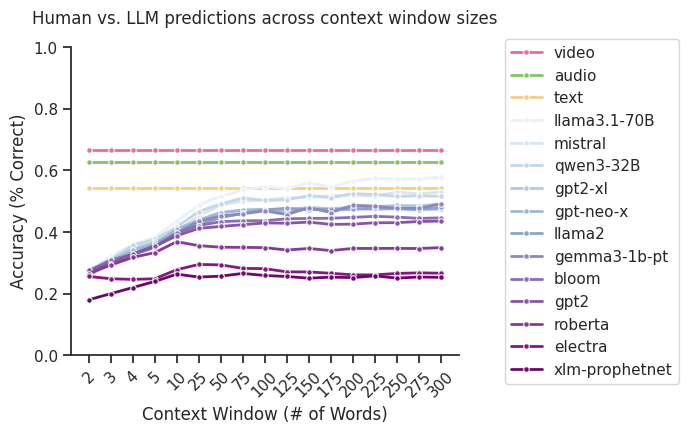

In [62]:
# df_results = pd.concat(df_results).reset_index(drop=True)
# df_results.to_csv(out_fn, index=False)
# df_results = pd.concat(df_results).reset_index(drop=True)

# use the accuracy within these results to get the order to plot the models
ordered_accuracy = utils.get_ordered_accuracy(df_results)

# always put humans first (audio, text) then CLM models, then MLM models
order = modality_list + MLM_MODELS
models_order = [item for item in ordered_accuracy if item not in order]
models_order = models_order + MLM_MODELS

human_models_order = modality_list + models_order

###################################
##### Make line plot of sizes #####
###################################
cmap = utils.create_colormap(dtype=CMAP_DTYPE, continuous=False, N_MODELS=N_MODELS)

sns.set(style='ticks', rc={'figure.figsize': FIG_SIZE})

variable = f'fasttext_top_word_accuracy'
sns.lineplot(df_results, x='window_number', y=variable, hue='modality', marker="o", markersize=4, ci=None, palette=cmap, linewidth=2, hue_order=human_models_order)

# plt.xticks(WINDOW_SIZES)
plt.xticks(range(len(WINDOW_SIZES)), WINDOW_SIZES, rotation=45)

plt.gca().legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel('Context Window (# of Words)')
plt.ylabel('Accuracy (% Correct)')
plt.ylim([0, 1.0])

# plt.title('Human predictions are more accurate than LLMs regardless of context window', y=1.05)
plt.title("Human vs. LLM predictions across context window sizes", y=1.05)
sns.despine()

/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:498: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax_joint.set_xticklabels(x_ticklabels)
/dartfs/rc/lab/F/FinnLab/tommy/isc_asynchrony_behavior/code/utils/plotting_utils.py:503: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.ax_joint.set_yticklabels(y_ticklabels)


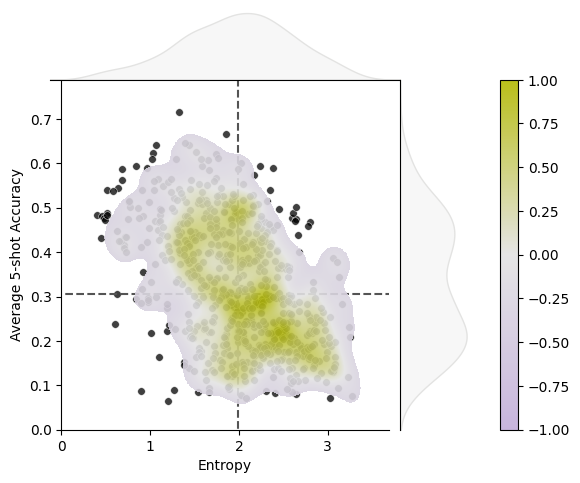

In [ ]:



# Load quadrants across tasks
df_quadrants = utils.load_task_model_quadrants(preproc_dir, models_dir, task_list, model_names, word_model)

# Create the density plot
# cmap = utils.create_colormap(dtype='human-model', continuous=True, N_MODELS=N_MODELS)
g = utils.create_joint_density_plot(df_tasks, df_quadrants, cmap=cmap)

# plt.savefig(os.path.join(plots_dir, "all-task_human-llm-comparison_quadrant-plot.pdf"), bbox_inches='tight', dpi=600)
# plt.close('all')